<p><img alt="UdeA logo" style="height: 180px !important; width: auto;" src="https://upload.wikimedia.org/wikipedia/commons/archive/f/fb/20161010213812%21Escudo-UdeA.svg" align="right" hspace="10px" vspace="0px"></p>


<h1> <b>Laboratorio 02 Estadística Descriptiva Básica 2

Física Computacional II 2026-2</b> </h1>

</div>

<!-- <br> le permite hacer espacios -->
<br>

<hr size=10 noshade color="green">
<p>


<div align="left">       

<h3><i><b>Felipe Quitian Gallego</b><br>  
Universidad de Antioquia <br>
Instituto de Física  <br>
</i></h3>
</div>

# Librerias

In [1]:
# Instalamos la librería fitter
!pip install fitter

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from fitter import Fitter, get_common_distributions, get_distributions
import numpy as np
import re
import seaborn as sns
from scipy import stats

# Series de tiempo

In [3]:
# 1. Leemos el dataset desde GitHub
url = 'https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Pandas_data_historical_dataEURUSD.csv'
df = pd.read_csv(url)

# 2. Definimos como índice la columna time
df['time'] = pd.to_datetime(df['time'])
df.set_index('time', inplace=True)

# 3. Obtenemos información del data frame
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5000 entries, 2022-07-25 13:00:00 to 2023-05-12 23:00:00
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5000 non-null   int64  
 1   open                5000 non-null   float64
 2   high                5000 non-null   float64
 3   low                 5000 non-null   float64
 4   close               5000 non-null   float64
 5   tick_volume         5000 non-null   int64  
 6   spread              5000 non-null   int64  
 7   real_volume         5000 non-null   int64  
 8   MeanCloseOpen       5000 non-null   float64
 9   Diff_Close          5000 non-null   float64
 10  Diff_Open           5000 non-null   float64
 11  Diff_MeanCloseOpen  5000 non-null   float64
dtypes: float64(8), int64(4)
memory usage: 507.8 KB


In [4]:
# 4. Determinamos si hay null, valores nan en el data frame
print(df.isna().sum())

Unnamed: 0            0
open                  0
high                  0
low                   0
close                 0
tick_volume           0
spread                0
real_volume           0
MeanCloseOpen         0
Diff_Close            0
Diff_Open             0
Diff_MeanCloseOpen    0
dtype: int64


In [5]:
# 5. Empleamos la notación Pascal Case y trabaja solo con la columna del precio de cierre
df.rename(columns={'close': 'PrecioCierre'}, inplace=True)

# Guardamos en una nueva variable en PascalCase trabajando solo con la columna PrecioCierre
PrecioCierreEurUsd = df[['PrecioCierre']]

# Visualizamos los primeros registros
print(PrecioCierreEurUsd.head())

                     PrecioCierre
time                             
2022-07-25 13:00:00       1.02345
2022-07-25 14:00:00       1.02299
2022-07-25 15:00:00       1.02457
2022-07-25 16:00:00       1.02485
2022-07-25 17:00:00       1.02181


In [6]:
# 6.
# Calculamos la diferencia entre horas con .diff()
PrecioCierreEurUsd['DiffPrice'] = PrecioCierreEurUsd['PrecioCierre'].diff()

# Eliminamos el valor nulo (NaN) que se genera en la primera fila al calcular la diferencia
PrecioCierreEurUsd.dropna(inplace=True)

# Verificamos que solo queden las dos columnas
print(PrecioCierreEurUsd.head())

                     PrecioCierre  DiffPrice
time                                        
2022-07-25 14:00:00       1.02299   -0.00046
2022-07-25 15:00:00       1.02457    0.00158
2022-07-25 16:00:00       1.02485    0.00028
2022-07-25 17:00:00       1.02181   -0.00304
2022-07-25 18:00:00       1.02099   -0.00082


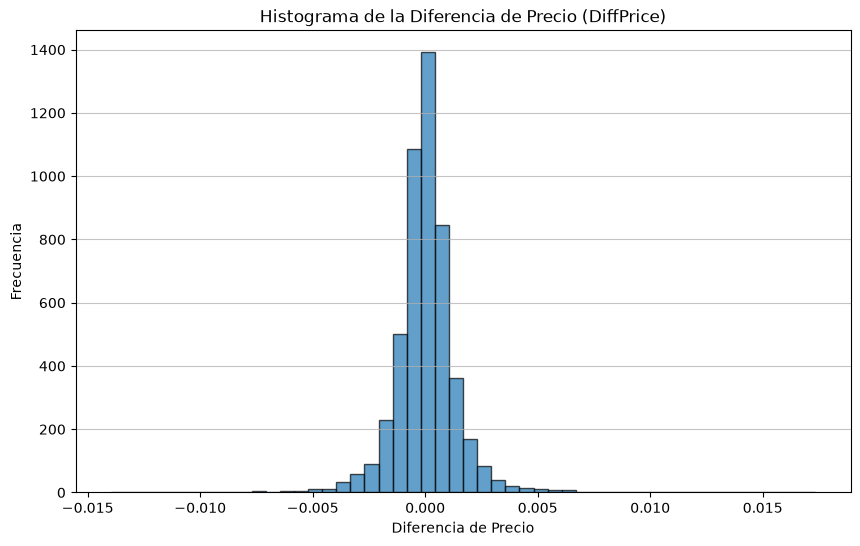

In [7]:
# Construimos el histograma para la nueva columna
plt.figure(figsize=(10, 6))
plt.hist(PrecioCierreEurUsd['DiffPrice'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Histograma de la Diferencia de Precio (DiffPrice)')
plt.xlabel('Diferencia de Precio')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)
plt.show()

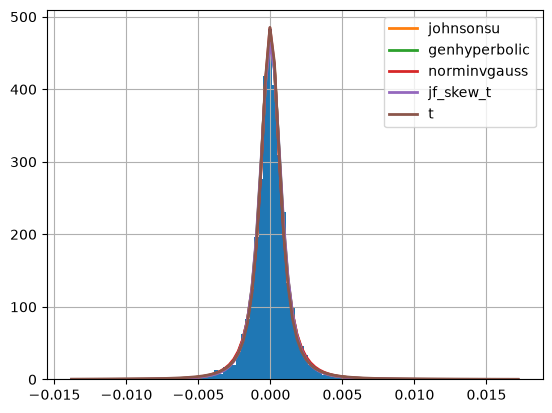

In [8]:
# Determinamos la mejor distribución estadística
# Extraemos los datos como un arreglo para Fitter
data = PrecioCierreEurUsd['DiffPrice'].values

# Configuramos Fitter
f = Fitter(data, distributions=get_distributions())
f.fit()

# f.summary() nos muestra un gráfico con el histograma y las mejores distribuciones superpuestas
f.summary()
plt.show()

In [9]:
# Identificamos la mejor distribución con en el error cuadrático medio
mejor_distribucion = f.get_best(method='sumsquare_error')
print(f"\nLa mejor distribución estadística (según sumsquare_error) y los parametros de esta: {mejor_distribucion}")


La mejor distribución estadística (según sumsquare_error) y los parametros de esta: {'johnsonsu': {'a': np.float64(-0.020654532350683215), 'b': np.float64(1.049797421216857), 'loc': np.float64(-1.5194909287993722e-05), 'scale': np.float64(0.0008808828671326262)}}


In [10]:
# 7. Seleccionamos solo los datos del 2023
Datos2023 = PrecioCierreEurUsd.loc['2023']

print(Datos2023.head())
print(f"Total de registros en 2023: {len(Datos2023)}")

                     PrecioCierre  DiffPrice
time                                        
2023-01-02 00:00:00       1.06796   -0.00200
2023-01-02 01:00:00       1.06965    0.00169
2023-01-02 02:00:00       1.07058    0.00093
2023-01-02 03:00:00       1.06896   -0.00162
2023-01-02 04:00:00       1.06880   -0.00016
Total de registros en 2023: 2278


In [11]:
# 8. Agrupación y promedios con diferentes periodicidades

print("--- Promedio con periodicidad de 15 días ---")
promedio_15_dias = PrecioCierreEurUsd.groupby(pd.Grouper(freq='15D')).mean()
print(promedio_15_dias.head())

print("\n--- Promedio con periodicidad de 1 semana ---")
promedio_1_semana = PrecioCierreEurUsd.groupby(pd.Grouper(freq='W')).mean()
print(promedio_1_semana.head())

print("\n--- Promedio con periodicidad de 1 mes ---")
promedio_1_mes = PrecioCierreEurUsd.groupby(pd.Grouper(freq='ME')).mean()
print(promedio_1_mes.head())

--- Promedio con periodicidad de 15 días ---
            PrecioCierre  DiffPrice
time                               
2022-07-25      1.019586  -0.000017
2022-08-09      1.016159  -0.000086
2022-08-24      0.996934   0.000015
2022-09-08      0.999753  -0.000065
2022-09-23      0.976675  -0.000035

--- Promedio con periodicidad de 1 semana ---
            PrecioCierre  DiffPrice
time                               
2022-07-31      1.018250  -0.000009
2022-08-07      1.020890  -0.000038
2022-08-14      1.025295   0.000065
2022-08-21      1.015174  -0.000181
2022-08-28      0.997196  -0.000065

--- Promedio con periodicidad de 1 mes ---
            PrecioCierre  DiffPrice
time                               
2022-07-31      1.018250  -0.000009
2022-08-31      1.012731  -0.000031
2022-09-30      0.990365  -0.000048
2022-10-31      0.983698   0.000016
2022-11-30      1.019872   0.000099


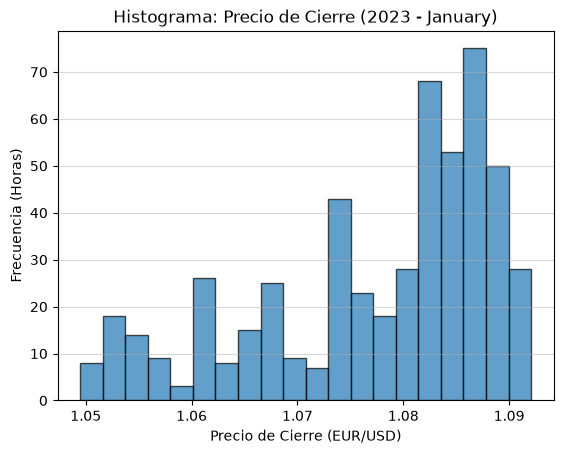

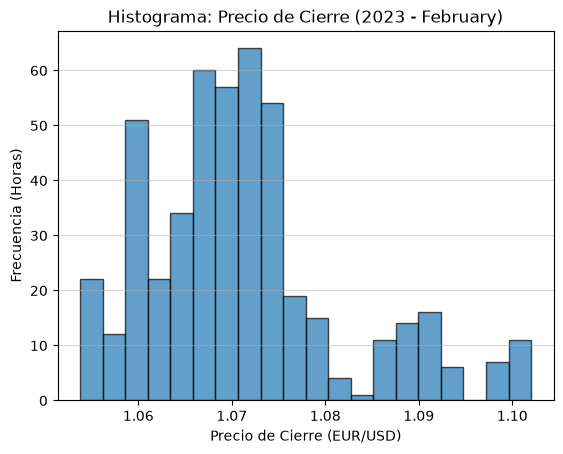

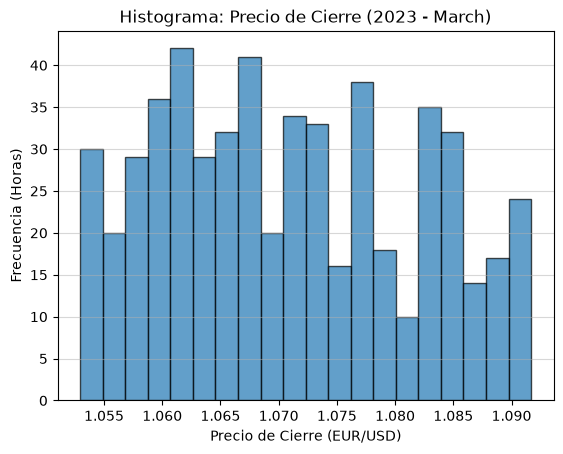

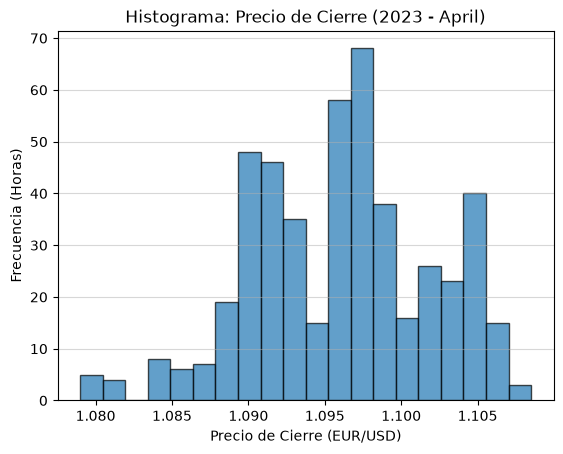

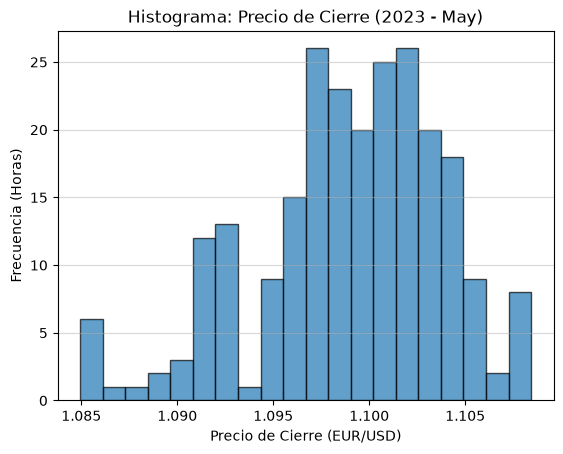

In [12]:
# 9. Histogramas mensuales para el año 2023

# Utilizamos el DataFrame Datos2023 y lo agrupamos por mes
grupos_mensuales_2023 = Datos2023.groupby(pd.Grouper(freq='ME'))

# Iteramos sobre el objeto groupby
for name, group in grupos_mensuales_2023:
    # Verificamos que el grupo tenga datos
    if not group.empty:

        # Construimos el histograma usando la columna PrecioCierre
        plt.hist(group['PrecioCierre'], bins=20, edgecolor='black', alpha=0.7)

        # Extraemos el nombre del mes y año para el título del gráfico
        mes_año = name.strftime('%Y - %B')

        plt.title(f'Histograma: Precio de Cierre ({mes_año})')
        plt.xlabel('Precio de Cierre (EUR/USD)')
        plt.ylabel('Frecuencia (Horas)')
        plt.grid(axis='y', alpha=0.5)
        plt.show()

# Análisis de datos con pandas

In [13]:
# 1. Leemos los datos desde la página web
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"

# Cargamos el dataset indicando que no tiene encabezados originales
df = pd.read_csv(url, header=None)

# 2. Renombramos las columnas en formato PascalCase
nombres_pascal_case = [
    "IdNumber", "Target",
    "RadiusMean", "TextureMean", "PerimeterMean", "AreaMean", "SmoothnessMean",
    "CompactnessMean", "ConcavityMean", "ConcavePointsMean", "SymmetryMean", "FractalDimensionMean",
    "RadiusSe", "TextureSe", "PerimeterSe", "AreaSe", "SmoothnessSe",
    "CompactnessSe", "ConcavitySe", "ConcavePointsSe", "SymmetrySe", "FractalDimensionSe",
    "RadiusWorst", "TextureWorst", "PerimeterWorst", "AreaWorst", "SmoothnessWorst",
    "CompactnessWorst", "ConcavityWorst", "ConcavePointsWorst", "SymmetryWorst", "FractalDimensionWorst"
]

# Asignamos los nombres PascalCase al DataFrame
df.columns = nombres_pascal_case

#  3. Obtenemos la información del DataFrame
# HEAD
print(df.head())

   IdNumber Target  RadiusMean  TextureMean  PerimeterMean  AreaMean  \
0    842302      M       17.99        10.38         122.80    1001.0   
1    842517      M       20.57        17.77         132.90    1326.0   
2  84300903      M       19.69        21.25         130.00    1203.0   
3  84348301      M       11.42        20.38          77.58     386.1   
4  84358402      M       20.29        14.34         135.10    1297.0   

   SmoothnessMean  CompactnessMean  ConcavityMean  ConcavePointsMean  ...  \
0         0.11840          0.27760         0.3001            0.14710  ...   
1         0.08474          0.07864         0.0869            0.07017  ...   
2         0.10960          0.15990         0.1974            0.12790  ...   
3         0.14250          0.28390         0.2414            0.10520  ...   
4         0.10030          0.13280         0.1980            0.10430  ...   

   RadiusWorst  TextureWorst  PerimeterWorst  AreaWorst  SmoothnessWorst  \
0        25.38         17.33

In [14]:
# TAIL
print(df.tail())

     IdNumber Target  RadiusMean  TextureMean  PerimeterMean  AreaMean  \
564    926424      M       21.56        22.39         142.00    1479.0   
565    926682      M       20.13        28.25         131.20    1261.0   
566    926954      M       16.60        28.08         108.30     858.1   
567    927241      M       20.60        29.33         140.10    1265.0   
568     92751      B        7.76        24.54          47.92     181.0   

     SmoothnessMean  CompactnessMean  ConcavityMean  ConcavePointsMean  ...  \
564         0.11100          0.11590        0.24390            0.13890  ...   
565         0.09780          0.10340        0.14400            0.09791  ...   
566         0.08455          0.10230        0.09251            0.05302  ...   
567         0.11780          0.27700        0.35140            0.15200  ...   
568         0.05263          0.04362        0.00000            0.00000  ...   

     RadiusWorst  TextureWorst  PerimeterWorst  AreaWorst  SmoothnessWorst  \
56

In [15]:
# INFO
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   IdNumber               569 non-null    int64  
 1   Target                 569 non-null    str    
 2   RadiusMean             569 non-null    float64
 3   TextureMean            569 non-null    float64
 4   PerimeterMean          569 non-null    float64
 5   AreaMean               569 non-null    float64
 6   SmoothnessMean         569 non-null    float64
 7   CompactnessMean        569 non-null    float64
 8   ConcavityMean          569 non-null    float64
 9   ConcavePointsMean      569 non-null    float64
 10  SymmetryMean           569 non-null    float64
 11  FractalDimensionMean   569 non-null    float64
 12  RadiusSe               569 non-null    float64
 13  TextureSe              569 non-null    float64
 14  PerimeterSe            569 non-null    float64
 15  AreaSe           

In [16]:
# DESCRIBE
print(df.describe())

           IdNumber  RadiusMean  TextureMean  PerimeterMean     AreaMean  \
count  5.690000e+02  569.000000   569.000000     569.000000   569.000000   
mean   3.037183e+07   14.127292    19.289649      91.969033   654.889104   
std    1.250206e+08    3.524049     4.301036      24.298981   351.914129   
min    8.670000e+03    6.981000     9.710000      43.790000   143.500000   
25%    8.692180e+05   11.700000    16.170000      75.170000   420.300000   
50%    9.060240e+05   13.370000    18.840000      86.240000   551.100000   
75%    8.813129e+06   15.780000    21.800000     104.100000   782.700000   
max    9.113205e+08   28.110000    39.280000     188.500000  2501.000000   

       SmoothnessMean  CompactnessMean  ConcavityMean  ConcavePointsMean  \
count      569.000000       569.000000     569.000000         569.000000   
mean         0.096360         0.104341       0.088799           0.048919   
std          0.014064         0.052813       0.079720           0.038803   
min        

In [17]:
# 4. Contabilizamos la cantidad de valores nulos
conteo_nulos = df.isna().sum()
print(conteo_nulos)
print(f"\nTotal de valores nulos en el DataFrame: {df.isna().sum().sum()}")

IdNumber                 0
Target                   0
RadiusMean               0
TextureMean              0
PerimeterMean            0
AreaMean                 0
SmoothnessMean           0
CompactnessMean          0
ConcavityMean            0
ConcavePointsMean        0
SymmetryMean             0
FractalDimensionMean     0
RadiusSe                 0
TextureSe                0
PerimeterSe              0
AreaSe                   0
SmoothnessSe             0
CompactnessSe            0
ConcavitySe              0
ConcavePointsSe          0
SymmetrySe               0
FractalDimensionSe       0
RadiusWorst              0
TextureWorst             0
PerimeterWorst           0
AreaWorst                0
SmoothnessWorst          0
CompactnessWorst         0
ConcavityWorst           0
ConcavePointsWorst       0
SymmetryWorst            0
FractalDimensionWorst    0
dtype: int64

Total de valores nulos en el DataFrame: 0


Como vemos este dataset tiene cero valores nulos, sin embargo para el caso donde obtengamos datos faltantes, lo que podriamos hacer para reemplazarlos depende del tipo de datos que temgamos:

Ideal si la columna sigue una distribución normal y no tiene valores atípicos extremos podemos reemplazar los valores nulos por el valor del promedio de los datos, la media.

Si los datos estan fuertemente sesgados o con muchos valores atípicos podriamos reemplazar los valores nulos con la mediana de estos.

Si las columnas son categóricas podriamos reemplazarlos por la moda, como reemplazar un diagnóstico faltante por el diagnóstico más frecuente.

Otra opción seria la eliminación de estos, pero solo es factible si el porcentaje de datos faltantes en toda la columna es muy pequeño, si su eliminación no afecta estadísticamente el tamaño de la muestra.

In [18]:
# 7.
# Mapeamos 'B' a 0 y 'M' a 1
df['DiagnosisNumeric'] = df['Target'].map({'B': 0, 'M': 1})
print(df[['Target', 'DiagnosisNumeric']])

    Target  DiagnosisNumeric
0        M                 1
1        M                 1
2        M                 1
3        M                 1
4        M                 1
..     ...               ...
564      M                 1
565      M                 1
566      M                 1
567      M                 1
568      B                 0

[569 rows x 2 columns]


In [19]:
# 8. Normalizamos las columnas numericas respecto a su media y desviación estándar
columnas_a_normalizar = df.columns.drop(['IdNumber', 'Target', 'DiagnosisNumeric'])

# Normalizamos utilizando la formula dada
for col in columnas_a_normalizar:
    df[col] = (df[col] - df[col].mean()) / df[col].std()

print(df[columnas_a_normalizar].describe().round(2).loc[['mean', 'std', 'min', 'max']])

      RadiusMean  TextureMean  PerimeterMean  AreaMean  SmoothnessMean  \
mean       -0.00         0.00          -0.00     -0.00           -0.00   
std         1.00         1.00           1.00      1.00            1.00   
min        -2.03        -2.23          -1.98     -1.45           -3.11   
max         3.97         4.65           3.97      5.25            4.77   

      CompactnessMean  ConcavityMean  ConcavePointsMean  SymmetryMean  \
mean             0.00           0.00              -0.00          0.00   
std              1.00           1.00               1.00          1.00   
min             -1.61          -1.11              -1.26         -2.74   
max              4.56           4.24               3.92          4.48   

      FractalDimensionMean  ...  RadiusWorst  TextureWorst  PerimeterWorst  \
mean                  0.00  ...        -0.00          0.00           -0.00   
std                   1.00  ...         1.00          1.00            1.00   
min                  -1.82  .

In [20]:
# 9. Agrupamos características similares y calculamos su promedio
caracteristicas = [
    'RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean',
    'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', "SymmetryMean", "FractalDimensionMean"
]

for feature in caracteristicas:
    # Usamos una expresión regular para remover la palabra 'Mean' al final y obtener el patrón base
    patron_base = re.sub(r'Mean$', '', feature)

    # Buscamos todas las columnas que comiencen con ese patrón (Mean, Se, Worst)
    columnas_similares = [col for col in df.columns if col.startswith(patron_base) and col in columnas_a_normalizar]

    # Calculamos el promedio a lo largo de las filas (axis=1) para esas columnas agrupadas
    nombre_nueva_columna = f"{patron_base}Agrupado"
    df[nombre_nueva_columna] = df[columnas_similares].mean(axis=1)


columnas_agrupadas = [col for col in df.columns if col.endswith('Agrupado')]
print(df[columnas_agrupadas].head())

   RadiusAgrupado  TextureAgrupado  PerimeterAgrupado  AreaAgrupado  \
0        1.822892        -1.331460           2.133644      1.822793   
1        1.377122        -0.532558           1.160448      1.512536   
2        1.438879        -0.115855           1.253866      1.397605   
3       -0.241121         0.092354          -0.185181     -0.533818   
4        1.438539        -1.135278           1.461481      1.411195   

   SmoothnessAgrupado  CompactnessAgrupado  ConcavityAgrupado  \
0            0.886604             2.403566           1.827201   
1           -0.602112            -0.536342          -0.203612   
2            0.390527             0.982746           0.809797   
3            2.453684             3.343920           1.573617   
4            0.660750             0.059090           0.936729   

   ConcavePointsAgrupado  SymmetryAgrupado  FractalDimensionAgrupado  
0               1.828182          2.037172                  1.698454  
1               0.631241         -0.3490

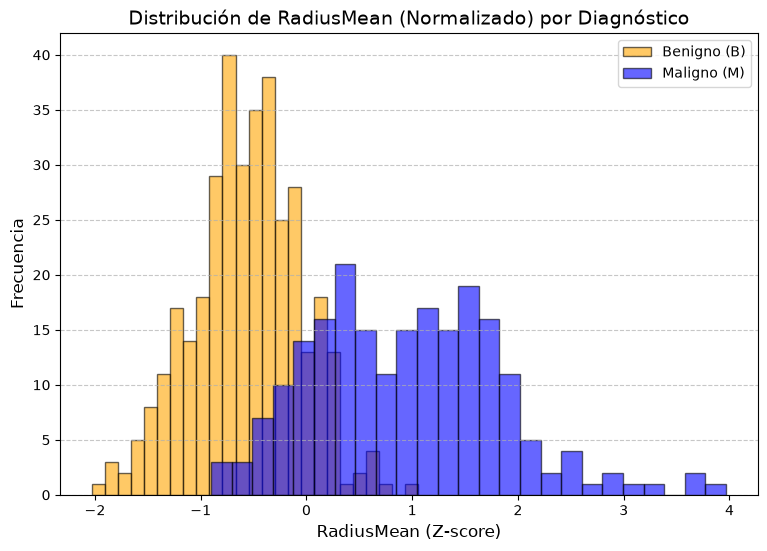

In [21]:
# 10. Realizamos el histograma de RadiusMean separado por etiquetas B y M
plt.figure(figsize=(9, 6))

# Filtramos la característica RadiusMean para cada tipo de diagnóstico
radius_B = df[df['Target'] == 'B']['RadiusMean']
radius_M = df[df['Target'] == 'M']['RadiusMean']

# Trazamos los histogramas superpuestos
plt.hist(radius_B, bins=25, color='orange', alpha=0.6, label='Benigno (B)', edgecolor='black')
plt.hist(radius_M, bins=25, color='blue', alpha=0.6, label='Maligno (M)', edgecolor='black')

plt.title('Distribución de RadiusMean (Normalizado) por Diagnóstico', fontsize=14)
plt.xlabel('RadiusMean (Z-score)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

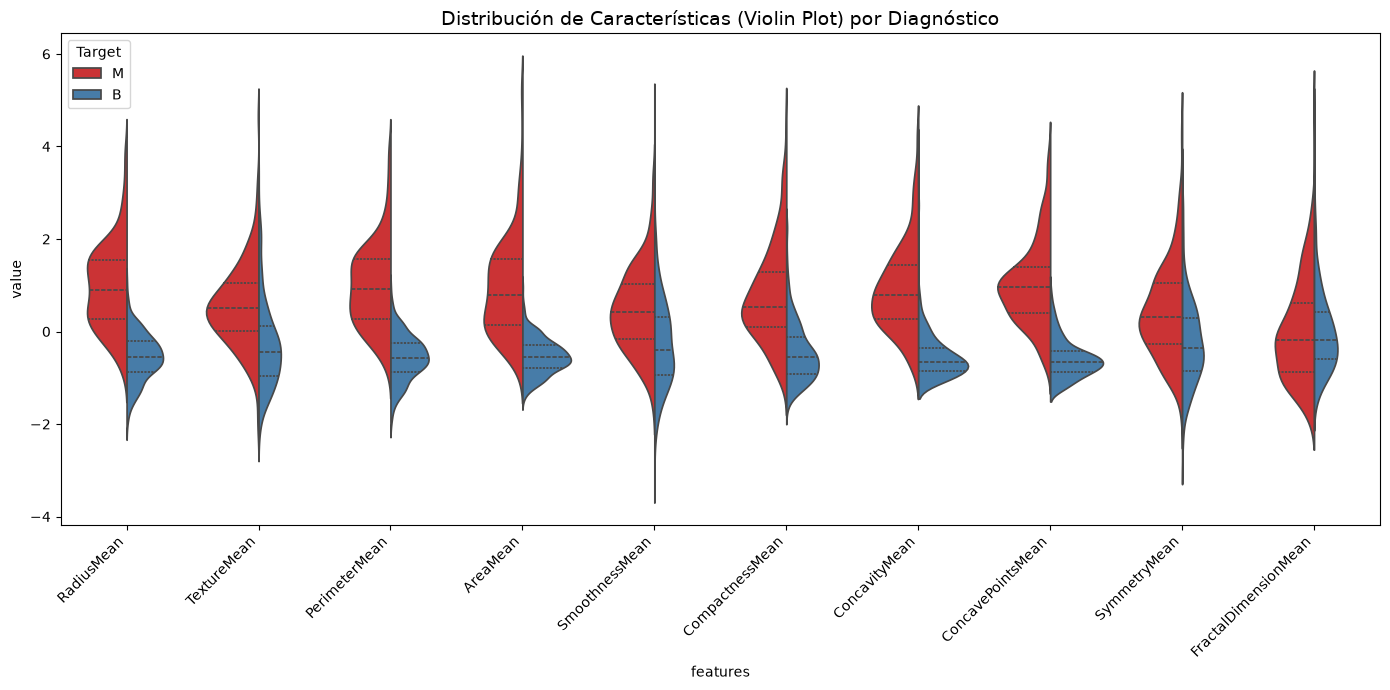

In [22]:
# 11. Gráficos de violín para múltiples características

# Definimos las columnas exactas que queremos graficar más la etiqueta (Target)
columnas_violin = [
    'Target', 'RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean',
    'SmoothnessMean', 'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean',
    'SymmetryMean', 'FractalDimensionMean'
]

# Graficamos múltiples variables
data_melt = pd.melt(df[columnas_violin], id_vars="Target", var_name="features", value_name="value")

plt.figure(figsize=(14, 7))
sns.violinplot(x="features", y="value", hue="Target", data=data_melt, split=True, inner="quart", palette="Set1")

plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Características (Violin Plot) por Diagnóstico', fontsize=14)
plt.tight_layout()
plt.show()

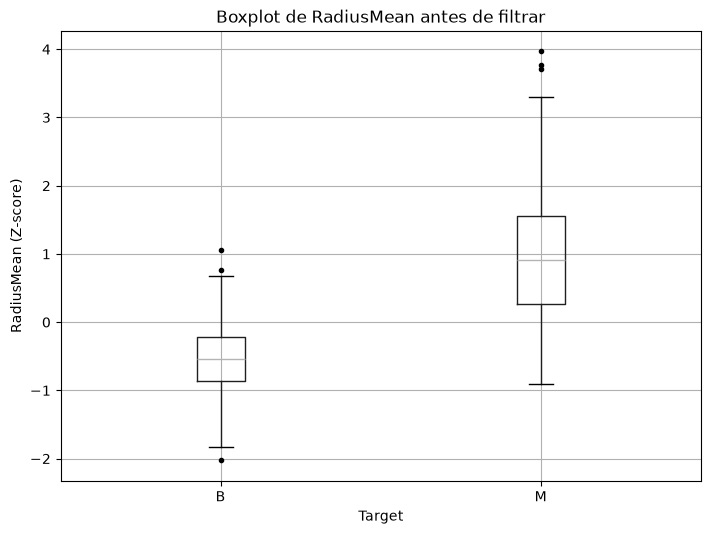

In [23]:
# 12. Determinamos y eliminamos valores atípicos en RadiusMean usando boxplot
df.boxplot(column="RadiusMean", by='Target', sym='k.', figsize=(8,6))
plt.title('Boxplot de RadiusMean antes de filtrar', fontsize=12)
plt.suptitle('')
plt.ylabel('RadiusMean (Z-score)')
plt.show()

In [24]:
# 12 Eliminamos usando el Rango Intercuartílico
Q1 = df['RadiusMean'].quantile(0.25)
Q3 = df['RadiusMean'].quantile(0.75)
IQR = Q3 - Q1

# Límite inferior y superior
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Filtramos el DataFrame conservando solo los valores que están dentro de los límites
df_limpio = df[~((df['RadiusMean'] < limite_inferior) | (df['RadiusMean'] > limite_superior))]

print(f"Filas originales: {len(df)}")
print(f"Filas después de limpiar: {len(df_limpio)}")
print(f"Outliers eliminados: {len(df) - len(df_limpio)}")

Filas originales: 569
Filas después de limpiar: 555
Outliers eliminados: 14


In [25]:
# 12. Alternativa usando Z-score

# Calculamos el Z-score absoluto para la columna RadiusMean y filtramos
df_limpio_z = df[(np.abs(stats.zscore(df['RadiusMean'])) < 3)]

print(f"Filas originales: {len(df)}")
print(f"Filas después de limpiar (Z-score): {len(df_limpio_z)}")
print(f"Outliers eliminados: {len(df) - len(df_limpio_z)}")

Filas originales: 569
Filas después de limpiar (Z-score): 564
Outliers eliminados: 5


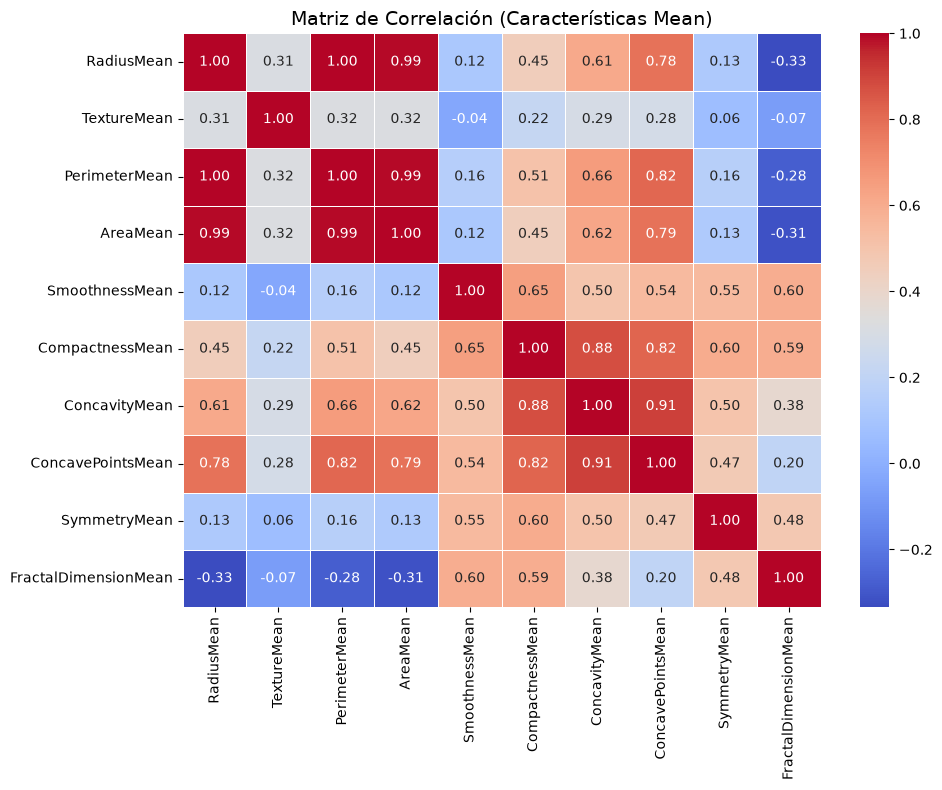

In [26]:
# 13. Matriz de correlación de las medias y Heatmap
columnas_corr = [
    'RadiusMean', 'TextureMean', 'PerimeterMean', 'AreaMean', 'SmoothnessMean',
    'CompactnessMean', 'ConcavityMean', 'ConcavePointsMean', 'SymmetryMean', 'FractalDimensionMean'
]

# Calculamos la matriz de correlación de Pearson
matriz_correlacion = df_limpio[columnas_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación (Características Mean)', fontsize=14)
plt.tight_layout()
plt.show()

14. Para este tipo de datos multivariados del cáncer de mama, podriamos analizar los datos con diferentes graficos:

Pairplot: Este es un una matriz de gráficos de dispersión. Nos permite cruzar cada variable contra todas las demás simultáneamente. Es ideal para ver qué par de características logran separar mejor las células benignas de las malignas en 2D.

Gráfico de Enjambre: Es muy similar al boxplot o violín, pero dibuja cada punto de dato individualmente sin que se solapen. Para datasets pequeños o medianos, esto permite ver la densidad real del dataset.

Gráfico de Dispersión: Permite comprimir la varianza de las 30 columnas en solo 2 y graficar un Scatter Plot. Asi si los puntos azules y naranjas se separan bien, significa que un algoritmo de Machine Learning tendrá gran éxito.

# Analisis y concluciones

### A) Hallazgos descriptivos

La falta de valores nulos garantiza la validez del dataset y de los análisis estadísticos que realizamos. Es importante la consistencia de los datos tras la normalización (Z-score), esto permitió poner todas las características en una escala comparable. Sin embargo, se encontró una variabilidad importante en los extremos de los datos de masa celular, donde con el analisis por rango intercuartílico identifico 14 datos atipicos.

La matriz de correlación nos muestra que datos como el radio medio (RadiusMean), el perímetro (PerimeterMean) y el área (AreaMean) tienen una correlaciones lineales casi perfectas (r ≈ 0.99).

Finalmente, se encontró que el comportamiento financiero y biológico siguen patrones modelables. La evaluación del error cuadrático medio para la serie de tiempo EUR/USD evidencia que las diferencias de precios no se deben a una distribución normal clásica, sino que se ajustan de forma óptima a una distribución Johnson SU, revelando colas características del mercado. Por otro lado, la varianza observada en dimensiones celulares no obedece a eventos aleatorios, sino que representan marcadores morfológicos que definen y diferencian un tumor maligno de uno benigno.

### B) Patrones visuales

Los histogramas de la distribución del radio medio (RadiusMean) tienen patrones diferenciados, debido a esto podemos decir que la muestra no obedece a una única distribución continua, sino a la superposición de subgrupos con características morfométricas diferentes según su diagnóstico (Benigno vs Maligno).

Los diagramas de violín nos muestran que al analizar características como el área o la concavidad, la clase benigna (B) es muy diferente a la maligna, teniendo medianas agrupadas en puntuaciones Z negativas y compactas.

Finalmente, el mapa de calor de correlación las variables de tamaño y forma coexisten con alta colinealidad, mientras que la dimensión fractal está completamente aislada de las demás, mostrando correlaciones inversas o nulas. Estas intensidades confirman que un algoritmo de Machine Learning tendria gran éxito al separar las clases basándose en estas agrupaciones.